# Generalization Across Materials Composition Space

## Objective

This notebook examines the structure of the composition feature space and tests how model performance changes when compositionally distinct groups are withheld during validation.

The analysis uses the composition descriptors generated in `01_data_selection_and_preprocessing.ipynb`. The main question is whether a classifier that performs well under ordinary stratified cross-validation retains similar performance when evaluated on groups that are separated in composition space.

## 1. Setup

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
)
from sklearn.model_selection import (
    LeaveOneGroupOut,
    StratifiedKFold,
    cross_validate,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
DATA_PATH = Path("../data/dielectric_composition_features.csv")

print(f"Python: {sys.version.split()[0]}")
print(f"pandas: {pd.__version__}")
print(f"scikit-learn: {sklearn.__version__}")

Python: 3.10.21
pandas: 2.3.3
scikit-learn: 1.7.2


## 2. Load data

In [2]:
df = pd.read_csv(DATA_PATH)

target_col = "target_ferroelectric"
metadata_cols = [col for col in ["material_id", "formula", "band_gap", target_col] if col in df.columns]
feature_cols = [col for col in df.columns if col not in metadata_cols]

X_raw = df[feature_cols].copy()
y = df[target_col].astype(int).copy()

print(f"Materials: {len(df)}")
print(f"Raw composition descriptors: {X_raw.shape[1]}")
print(f"Positive class fraction: {y.mean():.3f}")

Materials: 1056
Raw composition descriptors: 118
Positive class fraction: 0.671


## 3. Prepare composition descriptors

In [3]:
variance = VarianceThreshold()
X_nonconstant = variance.fit_transform(X_raw)
selected_features = X_raw.columns[variance.get_support()]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_nonconstant)

print(f"Non-constant descriptors: {X_nonconstant.shape[1]}")

Non-constant descriptors: 63


Zero-variance descriptors are removed before exploratory analysis because they do not contribute to distances or principal components. Standardization is used so that the analysis is not dominated by descriptors with larger numerical variance.

## 4. Principal-component analysis

In [4]:
pca = PCA(random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

explained = pd.Series(
    pca.explained_variance_ratio_,
    index=np.arange(1, X_pca.shape[1] + 1),
)

cumulative = explained.cumsum()

display(pd.DataFrame({
    "explained_variance_ratio": explained.head(10),
    "cumulative_variance": cumulative.head(10),
}).round(4))

,explained_variance_ratio,cumulative_variance
1,0.0254,0.0254
2,0.0247,0.0501
3,0.0238,0.0739
4,0.0231,0.0970
5,0.0228,0.1198
6,0.0219,0.1417
7,0.0212,0.1629
8,0.0206,0.1836
9,0.0201,0.2037
10,0.0201,0.2238


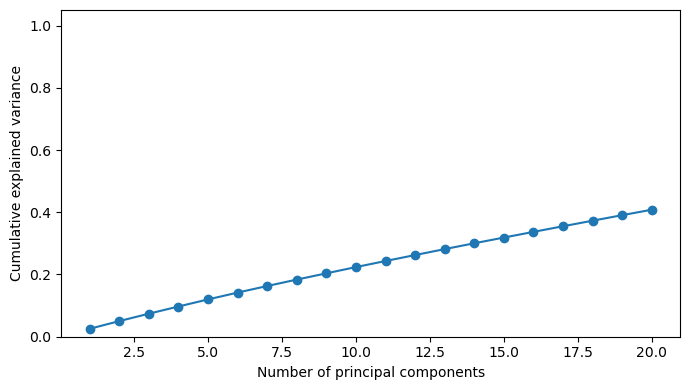

In [5]:
plt.figure(figsize=(7, 4))
plt.plot(
    np.arange(1, min(21, len(cumulative) + 1)),
    cumulative.iloc[:20],
    marker="o",
)
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

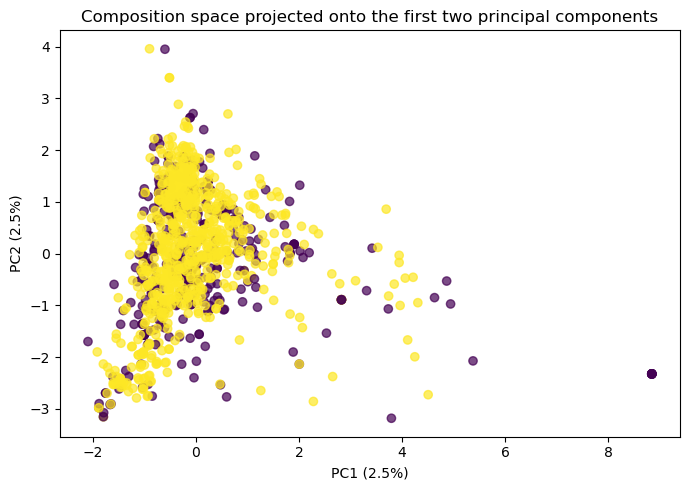

In [6]:
plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    alpha=0.7,
)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.title("Composition space projected onto the first two principal components")
plt.tight_layout()
plt.show()

The two-dimensional projection is used only for visualization. Group identification below is performed in a higher-dimensional PCA representation rather than directly in the plotted coordinates.

## 5. Select a PCA representation for grouping

In [7]:
variance_target = 0.90
n_components = int(np.searchsorted(cumulative.values, variance_target) + 1)

pca_group = PCA(
    n_components=n_components,
    random_state=RANDOM_STATE,
)
X_group_space = pca_group.fit_transform(X_scaled)

print(f"Components retained for grouping: {n_components}")
print(f"Explained variance retained: {pca_group.explained_variance_ratio_.sum():.3f}")

Components retained for grouping: 52
Explained variance retained: 0.901


The grouping space retains enough principal components to explain 90% of the variance in the standardized composition descriptors. This reduces dimensionality while preserving most of the variation relevant to composition-space separation.

## 6. Identify composition groups

In [8]:
cluster_rows = []

for n_clusters in range(3, 11):
    model = KMeans(
        n_clusters=n_clusters,
        random_state=RANDOM_STATE,
        n_init=20,
    )
    labels = model.fit_predict(X_group_space)
    score = silhouette_score(X_group_space, labels)

    cluster_rows.append({
        "n_clusters": n_clusters,
        "silhouette_score": score,
    })

cluster_scores = pd.DataFrame(cluster_rows)
display(cluster_scores.round(3))

,n_clusters,silhouette_score
0,3,-0.016
1,4,0.033
2,5,0.045
3,6,0.004
4,7,0.005
5,8,-0.013
6,9,0.006
7,10,0.041


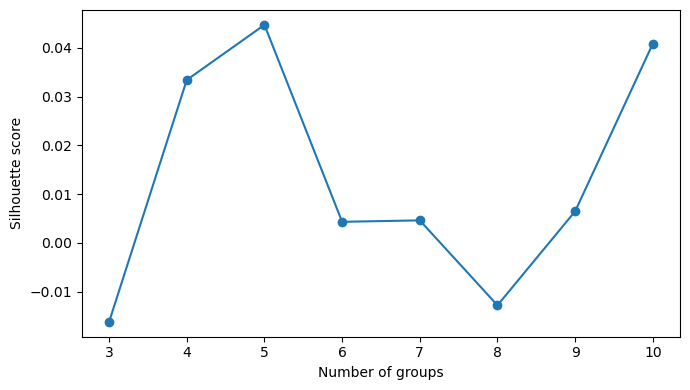

In [9]:
plt.figure(figsize=(7, 4))
plt.plot(
    cluster_scores["n_clusters"],
    cluster_scores["silhouette_score"],
    marker="o",
)
plt.xlabel("Number of groups")
plt.ylabel("Silhouette score")
plt.tight_layout()
plt.show()

In [10]:
best_k = int(
    cluster_scores.loc[
        cluster_scores["silhouette_score"].idxmax(),
        "n_clusters",
    ]
)

kmeans = KMeans(
    n_clusters=best_k,
    random_state=RANDOM_STATE,
    n_init=50,
)
groups = kmeans.fit_predict(X_group_space)

print(f"Selected number of composition groups: {best_k}")
print(pd.Series(groups).value_counts().sort_index())

Selected number of composition groups: 5
0     86
1     86
2    593
3    218
4     73
Name: count, dtype: int64


The number of groups is selected from a limited range using the silhouette score. These groups are used as a practical partition of composition space for validation; they are not treated as unique physical material classes.

## 7. Check grouping stability

In [11]:
reference_groups = groups.copy()
stability_scores = []

for seed in range(10):
    km = KMeans(
        n_clusters=best_k,
        random_state=seed,
        n_init=20,
    )
    labels = km.fit_predict(X_group_space)
    stability_scores.append(
        adjusted_rand_score(reference_groups, labels)
    )

stability = pd.Series(stability_scores, name="adjusted_rand_index")

print(f"Mean ARI across random initializations: {stability.mean():.3f}")
print(f"Minimum ARI: {stability.min():.3f}")

Mean ARI across random initializations: 0.100
Minimum ARI: -0.097


### Composition-space structure

Clustering of the PCA representation produced only weakly separated groups. The highest silhouette score was 0.045, and repeated K-means fits showed low stability (mean adjusted Rand index 0.100).
These results do not support an interpretation of the dataset as a small number of well-defined composition classes. The composition space is better viewed as a heterogeneous, largely continuous distribution.
The grouping is therefore used only as a controlled partition for the generalization test below, rather than as a physical classification of the materials.

## 8. Inspect group composition

In [12]:
group_summary = pd.DataFrame({
    "group": groups,
    "target": y.values,
})

group_stats = group_summary.groupby("group").agg(
    n_materials=("target", "size"),
    positive_fraction=("target", "mean"),
)

display(group_stats.round(3))

,n_materials,positive_fraction
group,,
0,86,0.640
1,86,0.616
2,593,0.669
3,218,0.706
4,73,0.685


In [13]:
X_group_df = pd.DataFrame(
    X_nonconstant,
    columns=selected_features,
    index=df.index,
)

for group_id in sorted(np.unique(groups)):
    group_mean = X_group_df.loc[groups == group_id].mean()
    top = group_mean.sort_values(ascending=False).head(6)

    print(f"Group {group_id} — top mean elemental fractions")
    display(
        top.rename("mean_fraction")
           .to_frame()
           .round(3)
    )

Group 0 — top mean elemental fractions


,mean_fraction
H,0.270
Mg,0.157
Ba,0.087
Sb,0.043
As,0.043
Na,0.039


Group 1 — top mean elemental fractions


,mean_fraction
N,0.294
Ca,0.176
B,0.074
Cl,0.044
Sr,0.034
P,0.031


Group 2 — top mean elemental fractions


,mean_fraction
F,0.188
S,0.081
Cl,0.073
K,0.062
Se,0.061
Br,0.050


Group 3 — top mean elemental fractions


,mean_fraction
O,0.480
Si,0.038
C,0.030
Sb,0.023
Na,0.021
As,0.019


Group 4 — top mean elemental fractions


,mean_fraction
Te,0.329
Ga,0.149
S,0.081
K,0.052
Se,0.051
Al,0.037


Performance varied substantially between the held-out composition-space partitions. Group 1 was the most difficult case, with a ROC-AUC of 0.714 and an accuracy of 0.605. Its average composition is distinguished by relatively large N and Ca fractions compared with the other partitions.
This observation is descriptive rather than a chemical classification. Given the weak clustering stability, the result is interpreted as evidence that model performance depends on the region of composition space being evaluated, rather than as failure on a distinct material family.

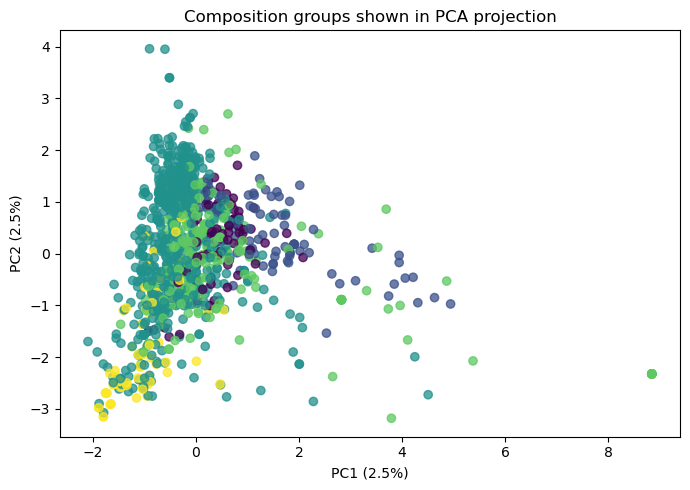

In [14]:
plt.figure(figsize=(7, 5))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=groups,
    alpha=0.75,
)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.title("Composition groups shown in PCA projection")
plt.tight_layout()
plt.show()

## 9. Compare ordinary and group-aware validation

In [15]:
rf = Pipeline([
    ("variance", VarianceThreshold()),
    ("model", RandomForestClassifier(
        n_estimators=400,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

scoring = {
    "roc_auc": "roc_auc",
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
}

stratified_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

random_cv_scores = cross_validate(
    rf,
    X_raw,
    y,
    cv=stratified_cv,
    scoring=scoring,
    n_jobs=-1,
)

random_cv_summary = {
    metric: (
        random_cv_scores[f"test_{metric}"].mean(),
        random_cv_scores[f"test_{metric}"].std(ddof=1),
    )
    for metric in scoring
}

random_cv_summary

{'roc_auc': (np.float64(0.9342454480196007), np.float64(0.015638031830732094)),
 'accuracy': (np.float64(0.8683716355181972),
  np.float64(0.019649840779169925)),
 'precision': (np.float64(0.887677855482701),
  np.float64(0.021457066948790498)),
 'recall': (np.float64(0.9210168814304265), np.float64(0.023028724445377326)),
 'f1': (np.float64(0.9037814647259056), np.float64(0.014352889559860773))}

In [16]:
logo = LeaveOneGroupOut()

logo_scores = cross_validate(
    rf,
    X_raw,
    y,
    cv=logo.split(X_raw, y, groups=groups),
    scoring=scoring,
    n_jobs=-1,
)

logo_summary = {
    metric: (
        logo_scores[f"test_{metric}"].mean(),
        logo_scores[f"test_{metric}"].std(ddof=1),
    )
    for metric in scoring
}

logo_summary

{'roc_auc': (np.float64(0.8546338264686861), np.float64(0.09345244983032744)),
 'accuracy': (np.float64(0.7261600157476106), np.float64(0.06974518001241138)),
 'precision': (np.float64(0.7764843731119374),
  np.float64(0.12125545583601878)),
 'recall': (np.float64(0.873805395403038), np.float64(0.1271497095621038)),
 'f1': (np.float64(0.8084690340795524), np.float64(0.040153724575868285))}

In [17]:
comparison_rows = []

for metric in scoring:
    random_mean, random_std = random_cv_summary[metric]
    logo_mean, logo_std = logo_summary[metric]

    comparison_rows.append({
        "metric": metric,
        "stratified_cv_mean": random_mean,
        "stratified_cv_std": random_std,
        "group_aware_mean": logo_mean,
        "group_aware_std": logo_std,
        "difference": logo_mean - random_mean,
    })

comparison = pd.DataFrame(comparison_rows)
display(comparison.round(3))

,metric,stratified_cv_mean,stratified_cv_std,group_aware_mean,group_aware_std,difference
0,roc_auc,0.934,0.016,0.855,0.093,-0.080
1,accuracy,0.868,0.020,0.726,0.070,-0.142
2,precision,0.888,0.021,0.776,0.121,-0.111
3,recall,0.921,0.023,0.874,0.127,-0.047
4,f1,0.904,0.014,0.808,0.040,-0.095


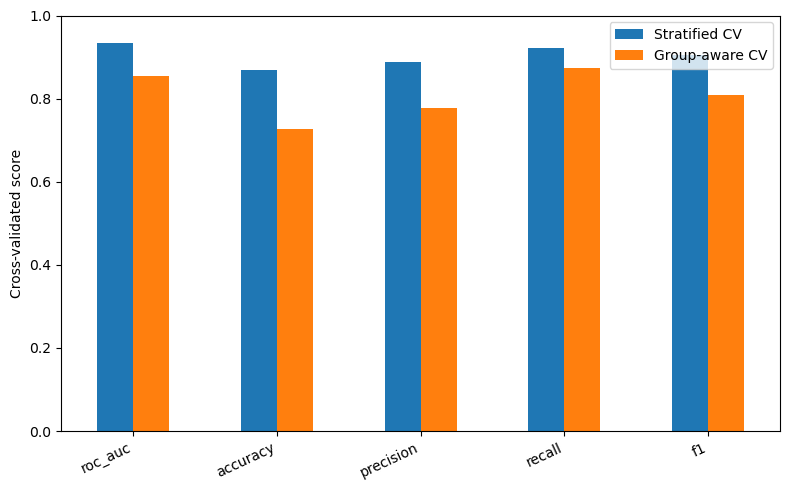

In [18]:
plot_df = comparison.set_index("metric")[
    ["stratified_cv_mean", "group_aware_mean"]
]

ax = plot_df.plot(kind="bar", figsize=(8, 5))
ax.set_ylabel("Cross-validated score")
ax.set_xlabel("")
ax.set_ylim(0, 1)
ax.legend(["Stratified CV", "Group-aware CV"])
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

### Generalization across composition space

Random stratified cross-validation gives a mean ROC-AUC of 0.934 ± 0.016 and an F1 score of 0.904 ± 0.014. When complete composition-space partitions are withheld, the corresponding scores decrease to 0.855 ± 0.093 and 0.808 ± 0.040.
The larger variation between held-out groups is also notable. ROC-AUC ranges from 0.714 to 0.952 depending on the excluded region.
The comparison indicates that predictive performance is sensitive to the composition domain represented in the training data. Random cross-validation therefore gives a more optimistic picture of performance than evaluation against withheld regions of composition space.
Because the clustering itself is weakly separated and unstable, the leave-one-group-out values should be interpreted as a stress test rather than a unique estimate of out-of-domain performance.

## 10. Per-group performance

In [19]:
fold_rows = []

for fold_id, (train_idx, test_idx) in enumerate(
    logo.split(X_raw, y, groups=groups)
):
    held_out_group = np.unique(groups[test_idx])[0]
    y_test = y.iloc[test_idx]

    fold_rows.append({
        "held_out_group": held_out_group,
        "n_test": len(test_idx),
        "positive_fraction": y_test.mean(),
        "roc_auc": logo_scores["test_roc_auc"][fold_id],
        "accuracy": logo_scores["test_accuracy"][fold_id],
        "f1": logo_scores["test_f1"][fold_id],
    })

fold_results = pd.DataFrame(fold_rows)
display(fold_results.round(3))

,held_out_group,n_test,positive_fraction,roc_auc,accuracy,f1
0,0,86,0.640,0.952,0.767,0.844
1,1,86,0.616,0.714,0.605,0.742
2,2,593,0.669,0.829,0.762,0.810
3,3,218,0.706,0.851,0.729,0.837
4,4,73,0.685,0.926,0.767,0.809


Per-group results help distinguish a general loss of performance from failure on one particularly unusual composition region. ROC-AUC can be undefined if a held-out group contains only one target class; such cases should be interpreted from the remaining metrics and the group composition itself.

## 11. Summary

This analysis uses composition-space grouping as a stress test for model generalization.

The main points are:

- PCA provides a lower-dimensional representation of the standardized composition descriptors without using the target labels;
- composition groups are identified in a multi-dimensional PCA space rather than in a two-dimensional visualization;
- group stability is checked across K-means initializations;
- ordinary stratified cross-validation is compared directly with leave-one-group-out validation;
- any reduction in group-aware performance is interpreted as evidence that prediction becomes more difficult when the test data occupy compositionally distinct regions.

The groups used here are data-driven partitions, not formal physical phases or material classes. Their value is as a reproducible way to probe extrapolation across composition space.